**1. Setup**

In [1]:
%pip install -q numpy pandas matplotlib seaborn scikit-learn requests

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: C:\Users\LENOVO\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [2]:
# Import all relevant libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
import requests
import time
from math import radians, sin, cos, sqrt, atan2
from datetime import datetime

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn. compose import ColumnTransformer
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    root_mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

In [3]:
# Configurations
pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x :.3f}")
sns.set_theme(style="darkgrid")

RANDOM_STATE = 100
TARGET_COL = "resale_price" # target column name

**2. Load Data**

In [4]:
import zipfile

zip_path = "ResaleFlatPrices.zip"

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall("ResaleFlatPrices")

In [5]:
# Loop through contents of zip file to retrieve all records and merge them
all_dfs = []

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    csv_files = [f for f in zip_ref.namelist() if f.endswith('.csv')]
    
    for csv_file in csv_files:
        with zip_ref.open(csv_file) as f:
            df = pd.read_csv(f)
            all_dfs.append(df)

# Combine into one DataFrame
combined_df = pd.concat(all_dfs, ignore_index=True)

print(f"✓ Loaded {len(all_dfs)} CSV files")
print(f"✓ Total records: {len(combined_df):,}")

✓ Loaded 5 CSV files
✓ Total records: 973,410


**3. Exploratory Data Analysis (EDA)**

In [6]:
print("=" * 80)
print("STEP 1: INITIAL DATA INSPECTION")
print("=" * 80)

print(f"\nDataset shape: {combined_df.shape}")
print(combined_df.info())

STEP 1: INITIAL DATA INSPECTION

Dataset shape: (973410, 11)
<class 'pandas.DataFrame'>
RangeIndex: 973410 entries, 0 to 973409
Data columns (total 11 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   month                973410 non-null  str    
 1   town                 973410 non-null  str    
 2   flat_type            973410 non-null  str    
 3   block                973410 non-null  str    
 4   street_name          973410 non-null  str    
 5   storey_range         973410 non-null  str    
 6   floor_area_sqm       973410 non-null  float64
 7   flat_model           973410 non-null  str    
 8   lease_commence_date  973410 non-null  int64  
 9   resale_price         973410 non-null  float64
 10  remaining_lease      264360 non-null  object 
dtypes: float64(2), int64(1), object(1), str(7)
memory usage: 134.5+ MB
None


In [7]:
combined_df.head()

,month,town,flat_type,block,street_name,storey_range,floor_area_sqm,flat_model,lease_commence_date,resale_price,remaining_lease
0,2000-01,ANG MO KIO,3 ROOM,170,ANG MO KIO AVE 4,07 TO 09,69.000,Improved,1986,147000.000,NaN
1,2000-01,ANG MO KIO,3 ROOM,174,ANG MO KIO AVE 4,04 TO 06,61.000,Improved,1986,144000.000,NaN
2,2000-01,ANG MO KIO,3 ROOM,216,ANG MO KIO AVE 1,07 TO 09,73.000,New Generation,1976,159000.000,NaN
3,2000-01,ANG MO KIO,3 ROOM,215,ANG MO KIO AVE 1,07 TO 09,73.000,New Generation,1976,167000.000,NaN
4,2000-01,ANG MO KIO,3 ROOM,218,ANG MO KIO AVE 1,07 TO 09,67.000,New Generation,1976,163000.000,NaN


In [8]:
num_cols = combined_df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = combined_df.select_dtypes(exclude=[np.number]).columns.tolist()

print("Target column:", TARGET_COL)
print("Numerical columns:", num_cols)
print("Categorical columns:", cat_cols)

Target column: resale_price
Numerical columns: ['floor_area_sqm', 'lease_commence_date', 'resale_price']
Categorical columns: ['month', 'town', 'flat_type', 'block', 'street_name', 'storey_range', 'flat_model', 'remaining_lease']


In [9]:
print(f"\nBasic statistics:\n{combined_df.describe()}")
print(f"\nUnique values per column:")
for col in combined_df.columns:
    print(f"  {col}: {combined_df[col].nunique()}")


Basic statistics:
       floor_area_sqm  lease_commence_date  resale_price
count      973410.000           973410.000    973410.000
mean           95.663             1988.752    336111.043
std            25.738               11.131    185249.136
min            28.000             1966.000      5000.000
25%            73.000             1981.000    200000.000
50%            93.000             1986.000    308000.000
75%           113.000             1996.000    435000.000
max           366.700             2021.000   1700000.000

Unique values per column:
  month: 435
  town: 27
  flat_type: 8
  block: 2755
  street_name: 595
  storey_range: 25
  floor_area_sqm: 227
  flat_model: 34
  lease_commence_date: 56
  resale_price: 10197
  remaining_lease: 747


In [10]:
print("\n" + "=" * 80)
print("STEP 2: MISSING VALUE ANALYSIS")
print("=" * 80)

missing_summary = pd.DataFrame({
    'Missing_Count': combined_df.isna().sum(),
    'Percentage': (combined_df.isna().sum() / len(combined_df)) * 100,
})
print(missing_summary)

# Handle missing values
# if combined_df.isnull().sum().sum() > 0:
#     # For critical columns, drop rows
#     critical_cols = ['resale_price', 'floor_area_sqm', 'lease_commence_date', 'town', 'flat_type']
#     combined_df = combined_df.dropna(subset=critical_cols)
#     print(f"\n✓ Dropped rows with missing critical values")
#     print(f"New shape: {combined_df.shape}")


STEP 2: MISSING VALUE ANALYSIS


                     Missing_Count  Percentage
month                            0       0.000
town                             0       0.000
flat_type                        0       0.000
block                            0       0.000
street_name                      0       0.000
storey_range                     0       0.000
floor_area_sqm                   0       0.000
flat_model                       0       0.000
lease_commence_date              0       0.000
resale_price                     0       0.000
remaining_lease             709050      72.842


**NOTE: remaining_lease has missing values**

In [11]:
# Lets convert month column which consists of month and year into a date type
# Create new column of column date and drop unnecessary column
combined_df['sold_year_month'] = pd.to_datetime(combined_df['month'])
combined_df.sort_values('sold_year_month')
combined_df = combined_df.drop(columns='month')

In [12]:
# get current year 
current_year = datetime.now().year  

# Extract year from lease_commence_date and calculate
combined_df['remaining_lease'] = 99 - (current_year - combined_df['lease_commence_date'].astype(int))

print("✓ Added remaining_lease column")
print(f"Sample: {combined_df[['lease_commence_date', 'remaining_lease']].head()}")


✓ Added remaining_lease column
Sample:    lease_commence_date  remaining_lease
0                 1986               59
1                 1986               59
2                 1976               49
3                 1976               49
4                 1976               49


In [13]:
print("\n" + "=" * 80)
print("STEP 3: DUPLICATE REMOVAL")
print("=" * 80)

initial_rows = len(combined_df)
duplicates = combined_df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")

print(f"Duplicate rows found:")
print(combined_df[combined_df.duplicated(keep=False)].head())

if duplicates > 0:
    final_df = combined_df.drop_duplicates()
    print(f"✓ Removed {initial_rows - len(combined_df)} duplicate rows")
    print(f"New shape: {final_df.shape}")


STEP 3: DUPLICATE REMOVAL
Duplicate rows found: 2009
Duplicate rows found:
           town flat_type block        street_name storey_range  \
21   ANG MO KIO    3 ROOM   443  ANG MO KIO AVE 10     07 TO 09   
22   ANG MO KIO    3 ROOM   443  ANG MO KIO AVE 10     07 TO 09   
175       BEDOK    3 ROOM    32      CHAI CHEE AVE     13 TO 15   
176       BEDOK    3 ROOM    32      CHAI CHEE AVE     13 TO 15   
284       BEDOK    4 ROOM   421       BEDOK NTH RD     13 TO 15   

     floor_area_sqm      flat_model  lease_commence_date  resale_price  \
21           67.000  New Generation                 1979    162000.000   
22           67.000  New Generation                 1979    162000.000   
175          65.000        Improved                 1974    165000.000   
176          65.000        Improved                 1974    165000.000   
284          92.000  New Generation                 1979    275000.000   

     remaining_lease sold_year_month  
21                52      2000-01-01 

In [14]:
# View value counts and number unique for each column to see if anything is odd
for col in final_df.select_dtypes(include=object):
    print(f"Number of unique values in {col}: {final_df[col].nunique()}")
    print(f"{final_df[col].value_counts()} \n")

Number of unique values in town: 27
town
TAMPINES           83274
YISHUN             73007
JURONG WEST        69527
WOODLANDS          68700
BEDOK              68698
ANG MO KIO         53708
HOUGANG            53030
BUKIT BATOK        46921
CHOA CHU KANG      40252
BUKIT MERAH        35999
SENGKANG           35933
PASIR RIS          34339
TOA PAYOH          33183
QUEENSTOWN         29879
GEYLANG            29304
BUKIT PANJANG      29115
CLEMENTI           28949
KALLANG/WHAMPOA    28622
JURONG EAST        25638
PUNGGOL            23652
SERANGOON          23519
BISHAN             21925
SEMBAWANG          15810
MARINE PARADE       8292
CENTRAL AREA        7448
BUKIT TIMAH         2614
LIM CHU KANG          63
Name: count, dtype: int64 

Number of unique values in flat_type: 8
flat_type
4 ROOM              371760
3 ROOM              306297
5 ROOM              205856
EXECUTIVE            72423
2 ROOM               13227
1 ROOM                1288
MULTI GENERATION       279
MULTI-GENERATION 

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_34568\1690453229.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in final_df.select_dtypes(include=object):


Number of unique values in flat_model: 34
flat_model
Model A                   212747
Improved                  178847
New Generation            115164
NEW GENERATION             78646
IMPROVED                   73296
MODEL A                    70234
Premium Apartment          51253
Simplified                 35974
Apartment                  26986
Standard                   26240
SIMPLIFIED                 23211
Maisonette                 18537
STANDARD                   17323
MAISONETTE                 12195
Model A2                   10616
APARTMENT                   9887
DBSS                        3899
Adjoined flat               1316
Model A-Maisonette          1166
MODEL A-MAISONETTE           981
Type S1                      503
Terrace                      464
2-room                       418
MULTI GENERATION             279
Multi Generation             271
TERRACE                      247
Type S2                      244
Premium Apartment Loft       134
Premium Maisonette     

In [15]:
# Flat type has two types of spelling - 'MULTI-GENERATION','MULTI GENERATION' lets change that
final_df['flat_type'] = final_df['flat_type'].str.replace('MULTI-GENERATION','MULTI GENERATION')
final_df['flat_type'].value_counts()

flat_type
4 ROOM              371760
3 ROOM              306297
5 ROOM              205856
EXECUTIVE            72423
2 ROOM               13227
1 ROOM                1288
MULTI GENERATION       550
Name: count, dtype: int64

In [16]:
# Flat model also seems to have many duplicates, lets change them
# mapping logic - https://sg.finance.yahoo.com/news/different-types-hdb-houses-call-020000642.html
correction_map = {'2-ROOM':'2-room',
                  'APARTMENT':'Apartment',
                  'Improved-Maisonette':'Executive Maisonette',
                  'IMPROVED-MAISONETTE':'Executive Maisonette',
                  'IMPROVED':'Improved',
                  'MAISONETTE':'Maisonette',
                  'Model A-Maisonette':'Maisonette',
                  'MODEL A-MAISONETTE':'Maisonette',
                  'MODEL A':'Model A',
                  'MULTI GENERATION':'Multi Generation',
                  'Premium Apartment Loft':'Premium Apartment',
                  'PREMIUM APARTMENT':'Premium Apartment',
                  'Premium Maisonette':'Executive Maisonette',
                  'SIMPLIFIED':'Simplified',
                  'STANDARD':'Standard',
                  'TERRACE':'Terrace',
                  'NEW GENERATION':'New Generation'}

final_df = final_df.replace({'flat_model': correction_map})

final_df['flat_model'].value_counts()

flat_model
Model A                 282981
Improved                252143
New Generation          193810
Simplified               59185
Premium Apartment        51393
Standard                 43563
Apartment                36873
Maisonette               32879
Model A2                 10616
DBSS                      3899
Adjoined flat             1316
Terrace                    711
Multi Generation           550
Type S1                    503
2-room                     439
Type S2                    244
Executive Maisonette       223
3Gen                        73
Name: count, dtype: int64

In [17]:
# Creating just a year sold column
final_df['sold_year'] = final_df['sold_year_month'].dt.strftime('%Y').astype('int')
final_df.info()

<class 'pandas.DataFrame'>
Index: 971401 entries, 0 to 973409
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   town                 971401 non-null  str           
 1   flat_type            971401 non-null  str           
 2   block                971401 non-null  str           
 3   street_name          971401 non-null  str           
 4   storey_range         971401 non-null  str           
 5   floor_area_sqm       971401 non-null  float64       
 6   flat_model           971401 non-null  str           
 7   lease_commence_date  971401 non-null  int64         
 8   resale_price         971401 non-null  float64       
 9   remaining_lease      971401 non-null  int64         
 10  sold_year_month      971401 non-null  datetime64[us]
 11  sold_year            971401 non-null  int64         
dtypes: datetime64[us](1), float64(2), int64(3), str(6)
memory usage: 143.1 MB


In [18]:
# View range of leases remaining in 2023
np.sort(final_df['remaining_lease'].unique())

# oldest hdb has 42 years remaining.
# youngest is 94 which is acceptable since you need to wait 5 years before being able to sell

array([39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55,
       56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72,
       73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89,
       90, 91, 92, 93, 94])

In [19]:
# load and view Property Information data
df_info = pd.read_csv('HDBPropertyInformation.csv')
df_info.info()

<class 'pandas.DataFrame'>
RangeIndex: 13267 entries, 0 to 13266
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   blk_no                 13267 non-null  str  
 1   street                 13267 non-null  str  
 2   max_floor_lvl          13267 non-null  int64
 3   year_completed         13267 non-null  int64
 4   residential            13267 non-null  str  
 5   commercial             13267 non-null  str  
 6   market_hawker          13267 non-null  str  
 7   miscellaneous          13267 non-null  str  
 8   multistorey_carpark    13267 non-null  str  
 9   precinct_pavilion      13267 non-null  str  
 10  bldg_contract_town     13267 non-null  str  
 11  total_dwelling_units   13267 non-null  int64
 12  1room_sold             13267 non-null  int64
 13  2room_sold             13267 non-null  int64
 14  3room_sold             13267 non-null  int64
 15  4room_sold             13267 non-null  int64
 1

Joining the DataFrames on Addresses

In [20]:
# Make standardised address columns for both DFs
final_df['address'] = final_df['block'] + " " + final_df['street_name']
df_info['address'] = df_info['blk_no'] + " " + df_info['street']

In [21]:
# Do a left join to merge the two data frames into one
# Since the resale df contains data of HDBs which do not exist anymore,
# we will be using the df with the property information for our left df since
# it only contains information from HDBs which still exist.
df_full = final_df.merge(df_info, how='left', on='address')

# Transpose and view df as it is too wide to view
df_full.head().T

,0,1,2,3,4
town,ANG MO KIO,ANG MO KIO,ANG MO KIO,ANG MO KIO,ANG MO KIO
flat_type,3 ROOM,3 ROOM,3 ROOM,3 ROOM,3 ROOM
block,170,174,216,215,218
street_name,ANG MO KIO AVE 4,ANG MO KIO AVE 4,ANG MO KIO AVE 1,ANG MO KIO AVE 1,ANG MO KIO AVE 1
storey_range,07 TO 09,04 TO 06,07 TO 09,07 TO 09,07 TO 09
floor_area_sqm,69.000,61.000,73.000,73.000,67.000
flat_model,Improved,Improved,New Generation,New Generation,New Generation
lease_commence_date,1986,1986,1976,1976,1976
resale_price,147000.000,144000.000,159000.000,167000.000,163000.000
remaining_lease,59,59,49,49,49


**Comments**

- There are some rows with no blk_no with no property information
- since there is no need for them, we can remove them

In [22]:
# count of how many rows have no blk_no
len(df_full[df_full['blk_no'].isna()]['address'].unique())

192

In [23]:
# since only 190 rows out ~900K rows of data are affected, we will remove them
df_full = df_full[df_full['blk_no'].notna()]

In [24]:
# remove repeated columns and rental information
df_full = df_full.drop(columns=['blk_no','street','1room_rental','2room_rental','3room_rental','other_room_rental','bldg_contract_town'])
# view df
df_full.info()

<class 'pandas.DataFrame'>
Index: 955385 entries, 0 to 971400
Data columns (total 30 columns):
 #   Column                 Non-Null Count   Dtype         
---  ------                 --------------   -----         
 0   town                   955385 non-null  str           
 1   flat_type              955385 non-null  str           
 2   block                  955385 non-null  str           
 3   street_name            955385 non-null  str           
 4   storey_range           955385 non-null  str           
 5   floor_area_sqm         955385 non-null  float64       
 6   flat_model             955385 non-null  str           
 7   lease_commence_date    955385 non-null  int64         
 8   resale_price           955385 non-null  float64       
 9   remaining_lease        955385 non-null  int64         
 10  sold_year_month        955385 non-null  datetime64[us]
 11  sold_year              955385 non-null  int64         
 12  address                955385 non-null  str           
 13  

In [25]:
# ============================================
# STEP 4: DATA TYPE CONVERSION & PARSING
# ============================================
print("\n" + "=" * 80)
print("STEP 4: DATA TYPE CONVERSION & PARSING")
print("=" * 80)

# Find middle of storey_range (e.g., Split "01 TO 05" → get both numbers → average → single storey_mid column)
split_storey = final_df['storey_range'].str.split(' TO ', expand=True).astype(int)
final_df['storey_mid'] = split_storey[[0,1]].mean(axis=1)

# Ensure numeric columns are numeric
numeric_cols = ['block', 'floor_area', 'lease_commence', 'resale_price']
for col in numeric_cols:
    if col in final_df.columns:
        final_df[col] = pd.to_numeric(final_df[col], errors='coerce')

print("✓ Ensured numeric columns have correct data types")


STEP 4: DATA TYPE CONVERSION & PARSING
✓ Ensured numeric columns have correct data types


In [26]:
# ============================================
# STEP 5: OUTLIER DETECTION & HANDLING
# ============================================
print("\n" + "=" * 80)
print("STEP 5: OUTLIER DETECTION & HANDLING")
print("=" * 80)

def detect_outliers_iqr(df, column, multiplier=1.5):
    """Detect outliers using IQR method"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - multiplier * IQR
    upper_bound = Q3 + multiplier * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Check key columns for outliers
outlier_cols = ['resale_price', 'floor_area_sqm']
outlier_stats = {}

for col in outlier_cols:
    if col in final_df.columns:
        outliers, lower, upper = detect_outliers_iqr(final_df, col)
        outlier_stats[col] = {
            'count': len(outliers),
            'percentage': len(outliers) / len(final_df) * 100,
            'lower_bound': lower,
            'upper_bound': upper
        }
        print(f"\n{col}:")
        print(f"  Outliers: {len(outliers)} ({len(outliers)/len(final_df)*100:.2f}%)")
        print(f"  Valid range: {lower:.2f} to {upper:.2f}")
        print(f"  Min: {final_df[col].min()}, Max: {final_df[col].max()}")

# For this project, keep outliers as they may represent genuine luxury/large flats
# But flag them for analysis
final_df['is_outlier_price'] = 0
outliers, lower, upper = detect_outliers_iqr(final_df, 'resale_price')
final_df.loc[outliers.index, 'is_outlier_price'] = 1
print(f"\n✓ Flagged {outliers.shape[0]} price outliers for analysis")


STEP 5: OUTLIER DETECTION & HANDLING

resale_price:
  Outliers: 24702 (2.54%)
  Valid range: -152500.00 to 787500.00
  Min: 5000.0, Max: 1700000.0

floor_area_sqm:
  Outliers: 2490 (0.26%)
  Valid range: 13.00 to 173.00
  Min: 28.0, Max: 366.7

✓ Flagged 24702 price outliers for analysis


In [27]:
print("\n" + "=" * 80)
print("STEP 6: FEATURE ENGINEERING")
print("=" * 80)

# Storey categories
final_df['storey_category'] = pd.cut(final_df['storey_mid'],
                                        bins=[0, 5, 10, 15, 50],
                                        labels=['Low', 'Mid-Low', 'Mid-High', 'High'])

print("✓ Created floor_area_category")

# Categorize towns into regions (based on Singapore planning areas)
region_mapping = {
    'ANG MO KIO': 'North-East',
    'BEDOK': 'East',
    'BISHAN': 'Central',
    'BUKIT BATOK': 'West',
    'BUKIT MERAH': 'Central',
    'BUKIT PANJANG': 'West',
    'BUKIT TIMAH': 'Central',
    'CENTRAL AREA': 'Central',
    'CHOA CHU KANG': 'West',
    'CLEMENTI': 'West',
    'GEYLANG': 'Central',
    'HOUGANG': 'North-East',
    'JURONG EAST': 'West',
    'JURONG WEST': 'West',
    'KALLANG/WHAMPOA': 'Central',
    'MARINE PARADE': 'Central',
    'PASIR RIS': 'East',
    'PUNGGOL': 'North-East',
    'QUEENSTOWN': 'Central',
    'SEMBAWANG': 'North',
    'SENGKANG': 'North-East',
    'SERANGOON': 'North-East',
    'TAMPINES': 'East',
    'TOA PAYOH': 'Central',
    'WOODLANDS': 'North',
    'YISHUN': 'North'
}

final_df['region'] = final_df['town'].map(region_mapping)
final_df['region'] = final_df['region'].fillna('Other')
print("✓ Created region feature")

# Flag mature vs non-mature estates
mature_estates = ['ANG MO KIO', 'BEDOK', 'BISHAN', 'BUKIT MERAH', 'BUKIT TIMAH',
                  'CENTRAL AREA', 'CLEMENTI', 'GEYLANG', 'KALLANG/WHAMPOA',
                  'MARINE PARADE', 'QUEENSTOWN', 'SERANGOON', 'TOA PAYOH']

final_df['is_mature_estate'] = final_df['town'].isin(mature_estates).astype(int)
print("✓ Created is_mature_estate flag")


STEP 6: FEATURE ENGINEERING
✓ Created floor_area_category
✓ Created region feature
✓ Created is_mature_estate flag


In [28]:
final_df['region'].value_counts()

region
West          240402
Central       197266
North-East    189842
East          186311
North         157517
Other             63
Name: count, dtype: int64

In [29]:
# ============================================
# STEP 7: AGGREGATED FEATURES (TOWN-LEVEL STATISTICS)
# ============================================
print("\n" + "=" * 80)
print("STEP 11: AGGREGATED FEATURES (TOWN-LEVEL STATISTICS)")
print("=" * 80)

# Town-level median price (useful for understanding relative value)
town_median_price = final_df.groupby('town')['resale_price'].median()
final_df['town_median_price'] = final_df['town'].map(town_median_price)
final_df['price_vs_town_median'] = final_df['resale_price'] / final_df['town_median_price']
print("✓ Created town_median_price")


STEP 11: AGGREGATED FEATURES (TOWN-LEVEL STATISTICS)
✓ Created town_median_price


In [30]:
# Remove negative or zero prices
print("\n1. Validating resale_price...")
print(f"   Min price: ${final_df['resale_price'].min():,.0f}")
print(f"   Max price: ${final_df['resale_price'].max():,.0f}")

invalid_prices = final_df[final_df['resale_price'] <= 0]
print(f"   Found {len(invalid_prices)} records with price <= 0")
final_df = final_df[final_df['resale_price'] > 0]

# Rule 2: Floor area must be positive and realistic
print("\n2. Validating floor_area...")
print(f"   Min area: {final_df['floor_area_sqm'].min()} sqm")
print(f"   Max area: {final_df['floor_area_sqm'].max()} sqm")

invalid_area = final_df[final_df['floor_area_sqm'] <= 0]
print(f"   Found {len(invalid_area)} records with area <= 0")
final_df = final_df[final_df['floor_area_sqm'] > 0]


1. Validating resale_price...
   Min price: $5,000
   Max price: $1,700,000
   Found 0 records with price <= 0

2. Validating floor_area...
   Min area: 28.0 sqm
   Max area: 366.7 sqm
   Found 0 records with area <= 0


Heatmap saved as correlation_heatmap.png


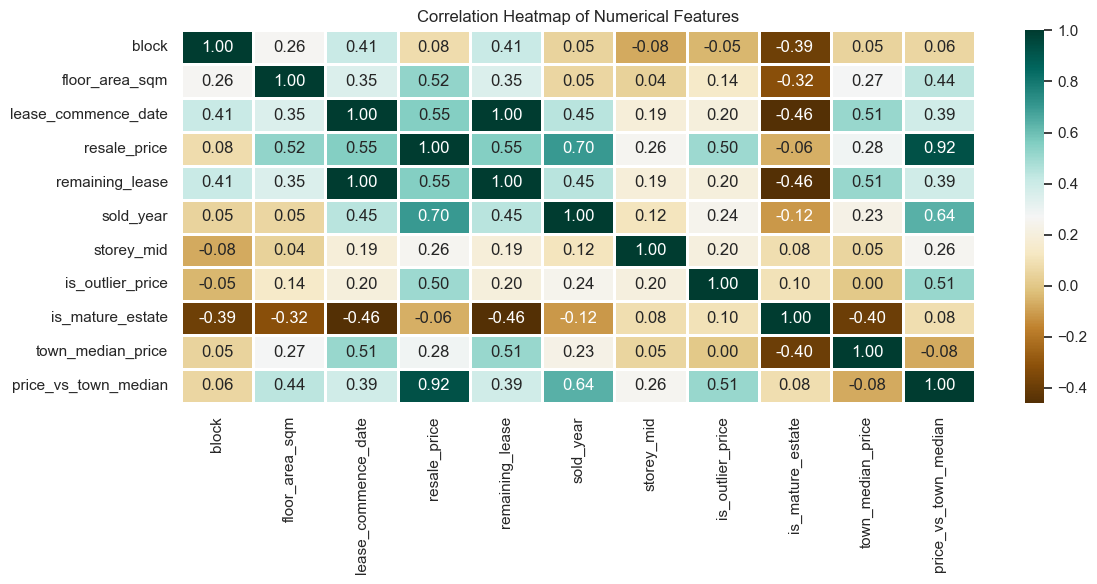

In [31]:
numerical_dataset = final_df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(12, 6))
sns.heatmap(numerical_dataset.corr(),
            cmap='BrBG',
            fmt='.2f',
            linewidths=2,
            annot=True)
plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
print("Heatmap saved as correlation_heatmap.png")

In [32]:
print(final_df.columns)

Index(['town', 'flat_type', 'block', 'street_name', 'storey_range',
       'floor_area_sqm', 'flat_model', 'lease_commence_date', 'resale_price',
       'remaining_lease', 'sold_year_month', 'sold_year', 'address',
       'storey_mid', 'is_outlier_price', 'storey_category', 'region',
       'is_mature_estate', 'town_median_price', 'price_vs_town_median'],
      dtype='str')


In [33]:
final_df['year'] = pd.to_datetime(final_df['sold_year_month']).dt.year

In [34]:
print("\n" + "=" * 80)
print("INFLATION ADJUSTMENT TO 2008 BASE YEAR")
print("=" * 80)

singapore_cpi = {
    1990: 65.8,
    1991: 68.5,
    1992: 70.9,
    1993: 73.1,
    1994: 75.9,
    1995: 77.6,
    1996: 79.1,
    1997: 81.0,
    1998: 80.5,
    1999: 80.7,
    2000: 82.1,
    2001: 83.1,
    2002: 82.6,
    2003: 83.1,
    2004: 84.8,
    2005: 85.3,
    2006: 86.3,
    2007: 88.5,
    2008: 100.0,
    2009: 100.6,
    2010: 103.4,
    2011: 108.6,
    2012: 113.2,
    2013: 115.9,
    2014: 117.0,
    2015: 116.6,
    2016: 116.5,
    2017: 117.2,
    2018: 117.9,
    2019: 118.5,
    2020: 118.2,
    2021: 120.8,
    2022: 127.0,
    2023: 132.8,
    2024: 136.5,
    2025: 140.0,
    2026: 143.0
}

print("\n1. Mapping CPI values to transaction years...")

# use sold_year directly if that's the column you already have
final_df['cpi'] = final_df['sold_year'].map(singapore_cpi)

missing_cpi = final_df[final_df['cpi'].isna()]

if len(missing_cpi) > 0:
    print(f"   Warning: {len(missing_cpi)} records have missing CPI values")
    print(f"   Years with missing CPI: {missing_cpi['sold_year'].unique()}")

    for year in missing_cpi['sold_year'].unique():
        if year < min(singapore_cpi.keys()):
            final_df.loc[final_df['sold_year'] == year, 'cpi'] = singapore_cpi[min(singapore_cpi.keys())]
            print(f"   Used {min(singapore_cpi.keys())} CPI for year {year}")
        elif year > max(singapore_cpi.keys()):
            final_df.loc[final_df['sold_year'] == year, 'cpi'] = singapore_cpi[max(singapore_cpi.keys())]
            print(f"   Used {max(singapore_cpi.keys())} CPI for year {year}")
else:
    print("   All years have CPI values")

base_year_cpi = 100.0

print("\n2. Calculating inflation-adjusted prices...")
final_df['resale_price_real_2008'] = (
    final_df['resale_price'] * (base_year_cpi / final_df['cpi'])
).round(2)

print("Created resale_price_real_2008")

final_df['inflation_adjustment_factor'] = base_year_cpi / final_df['cpi']

print("\n3. Sample of inflation adjustment:")
print("=" * 100)
sample_years = final_df.groupby('sold_year').first()[
    ['resale_price', 'cpi', 'inflation_adjustment_factor', 'resale_price_real_2008']
].head(10)
print(sample_years)

print("\n4. Price comparison statistics:")
print("=" * 100)
print(f"Nominal (Original) Prices:")
print(f"  Mean:   ${final_df['resale_price'].mean():,.2f}")
print(f"  Median: ${final_df['resale_price'].median():,.2f}")
print(f"  Min:    ${final_df['resale_price'].min():,.2f}")
print(f"  Max:    ${final_df['resale_price'].max():,.2f}")

print(f"\nReal (2008-adjusted) Prices:")
print(f"  Mean:   ${final_df['resale_price_real_2008'].mean():,.2f}")
print(f"  Median: ${final_df['resale_price_real_2008'].median():,.2f}")
print(f"  Min:    ${final_df['resale_price_real_2008'].min():,.2f}")
print(f"  Max:    ${final_df['resale_price_real_2008'].max():,.2f}")

print("\n5. Real vs Nominal price trends by year:")
print("=" * 100)
yearly_comparison = final_df.groupby('sold_year').agg({
    'resale_price': 'median',
    'resale_price_real_2008': 'median',
    'cpi': 'first'
}).round(2)

yearly_comparison['real_vs_nominal_diff'] = (
    yearly_comparison['resale_price_real_2008'] - yearly_comparison['resale_price']
)

yearly_comparison['real_vs_nominal_pct'] = (
    (yearly_comparison['resale_price_real_2008'] / yearly_comparison['resale_price'] - 1) * 100
).round(2)

print(yearly_comparison.head(30))


INFLATION ADJUSTMENT TO 2008 BASE YEAR

1. Mapping CPI values to transaction years...
   All years have CPI values

2. Calculating inflation-adjusted prices...
Created resale_price_real_2008

3. Sample of inflation adjustment:
           resale_price    cpi  inflation_adjustment_factor  \
sold_year                                                     
1990           9000.000 65.800                        1.520   
1991           6000.000 68.500                        1.460   
1992           7800.000 70.900                        1.410   
1993          57000.000 73.100                        1.368   
1994          24000.000 75.900                        1.318   
1995          90000.000 77.600                        1.289   
1996          48000.000 79.100                        1.264   
1997         118000.000 81.000                        1.235   
1998         136000.000 80.500                        1.242   
1999          88000.000 80.700                        1.239   

           resa

Now we are going to get the nearest MRT, community club, clinics, parks & hawker centres. First we import the relevant libraries.

In [36]:
import pandas as pd
import numpy as np
import geopandas as gpd
import requests
import time
import re
from pathlib import Path

We now set the necessary settings configurations.

In [38]:
AMENITY_DIR = Path("amenity_layers")
MRT_FILE = "LTAMRTStationExitGEOJSON.geojson"
CACHE_FILE = "address_coords_cache.csv"
OUTPUT_CSV = "final_df_with_location_features.csv"

RADIUS_M = 1000
GEOCODE_SLEEP = 0.25
SAVE_EVERY = 100

We build our helper functions.

In [39]:
def log(msg):
    print(f"[INFO] {msg}")

def find_file(folder, keywords):
    folder = Path(folder)
    files = list(folder.glob("*"))
    for f in files:
        name = f.name.lower()
        if all(k.lower() in name for k in keywords):
            return str(f)
    raise FileNotFoundError(f"Could not find file in {folder} matching keywords: {keywords}")

def normalize_to_wgs84(gdf):
    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=4326)
    return gdf.to_crs(epsg=4326)

def project_to_sv21(gdf):
    if gdf.crs is None:
        gdf = gdf.set_crs(epsg=4326)
    return gdf.to_crs(epsg=3414)

def build_points_gdf(df, lat_col="latitude", lon_col="longitude"):
    out = df.dropna(subset=[lat_col, lon_col]).copy()
    return gpd.GeoDataFrame(
        out,
        geometry=gpd.points_from_xy(out[lon_col], out[lat_col]),
        crs="EPSG:4326"
    )

def extract_from_description(desc, field_name):
    if pd.isna(desc):
        return None

    text = str(desc)
    patterns = [
        rf"{field_name}\s*</th>\s*<td[^>]*>\s*(.*?)\s*</td>",
        rf"{field_name}\s*</td>\s*<td[^>]*>\s*(.*?)\s*</td>",
        rf"{field_name}\s*[:\-]\s*(.*?)(?:<br|</td>|</tr>|$)",
    ]

    for pattern in patterns:
        m = re.search(pattern, text, flags=re.IGNORECASE | re.DOTALL)
        if m:
            value = re.sub(r"<.*?>", "", m.group(1)).strip()
            return value if value else None
    return None

geocoding + nearest/count functions

In [40]:
def geocode_address_onemap(address, session, max_retries=5, base_sleep=1.5):
    url = "https://www.onemap.gov.sg/api/common/elastic/search"
    params = {
        "searchVal": address,
        "returnGeom": "Y",
        "getAddrDetails": "Y",
        "pageNum": 1
    }

    for attempt in range(max_retries):
        try:
            r = session.get(url, params=params, timeout=20)
            r.raise_for_status()
            data = r.json()

            if data.get("found", 0) > 0 and len(data.get("results", [])) > 0:
                first = data["results"][0]
                return {
                    "address": address,
                    "latitude": float(first["LATITUDE"]),
                    "longitude": float(first["LONGITUDE"]),
                    "matched_address": first.get("ADDRESS"),
                    "status": "ok"
                }
            else:
                return {
                    "address": address,
                    "latitude": np.nan,
                    "longitude": np.nan,
                    "matched_address": None,
                    "status": "not_found"
                }

        except Exception as e:
            wait = base_sleep * (2 ** attempt)
            print(f"Retry {attempt+1}/{max_retries} failed for: {address} | {type(e).__name__}: {e}")
            time.sleep(wait)

    return {
        "address": address,
        "latitude": np.nan,
        "longitude": np.nan,
        "matched_address": None,
        "status": "failed"
    }

def add_nearest(points_gdf, layer_gdf, name_col, prefix, lat_col, lon_col):
    points_sv = project_to_sv21(points_gdf[[lat_col, lon_col, "geometry"]].copy())
    layer_sv = project_to_sv21(layer_gdf[[name_col, "geometry"]].dropna(subset=["geometry"]).copy())

    joined = gpd.sjoin_nearest(
        points_sv,
        layer_sv,
        how="left",
        distance_col=f"nearest_{prefix}_distance_m"
    )

    out = joined[[lat_col, lon_col, name_col, f"nearest_{prefix}_distance_m"]].copy()
    out = out.rename(columns={name_col: f"nearest_{prefix}_name"})
    out[f"nearest_{prefix}_distance_m"] = out[f"nearest_{prefix}_distance_m"].round(1)

    return out.drop_duplicates(subset=[lat_col, lon_col])

def add_count_within_radius(
    points_gdf,
    layer_gdf,
    prefix,
    lat_col,
    lon_col,
    radius_m=1000,
    unique_by=None
):
    layer = layer_gdf.dropna(subset=["geometry"]).copy()
    layer = project_to_sv21(layer)

    if unique_by is not None:
        layer = layer[[unique_by, "geometry"]].dropna(subset=[unique_by]).copy()
        count_key = unique_by
    else:
        count_key = "__feature_id"
        layer[count_key] = layer.index.astype(str)

    buffers = points_gdf[[lat_col, lon_col, "geometry"]].copy()
    buffers = project_to_sv21(buffers)
    buffers["geometry"] = buffers.geometry.buffer(radius_m)

    joined = gpd.sjoin(
        buffers,
        layer[[count_key, "geometry"]],
        how="left",
        predicate="intersects"
    )

    joined = joined.dropna(subset=[count_key]).copy()

    counts = (
        joined[[lat_col, lon_col, count_key]]
        .drop_duplicates()
        .groupby([lat_col, lon_col])[count_key]
        .nunique()
        .reset_index(name=f"num_{prefix}_within_{int(radius_m)}m")
    )

    out = points_gdf[[lat_col, lon_col]].drop_duplicates().copy()
    out = out.merge(counts, on=[lat_col, lon_col], how="left")
    out[f"num_{prefix}_within_{int(radius_m)}m"] = (
        out[f"num_{prefix}_within_{int(radius_m)}m"].fillna(0).astype(int)
    )
    return out

layer builders

In [45]:
def build_mrt_layer(mrt_file):
    mrt_gdf = gpd.read_file(mrt_file)
    mrt_gdf = normalize_to_wgs84(mrt_gdf)

    mrt_gdf["lon"] = mrt_gdf.geometry.x
    mrt_gdf["lat"] = mrt_gdf.geometry.y

    mrt_station = mrt_gdf.groupby("STATION_NA", as_index=False)[["lat", "lon"]].mean()

    return gpd.GeoDataFrame(
        mrt_station.rename(columns={"STATION_NA": "mrt_name"}),
        geometry=gpd.points_from_xy(mrt_station["lon"], mrt_station["lat"]),
        crs="EPSG:4326"
    )

def build_clinic_layer(amenity_dir):
    clinic_file = find_file(amenity_dir, ["chas"])
    clinics = gpd.read_file(clinic_file)
    clinics = normalize_to_wgs84(clinics)

    if "Description" in clinics.columns:
        clinics["clinic_name"] = clinics["Description"].apply(
            lambda x: extract_from_description(x, "HCI_NAME")
        )
        clinics["hci_code"] = clinics["Description"].apply(
            lambda x: extract_from_description(x, "HCI_CODE")
        )
    else:
        if "NAME" in clinics.columns:
            clinics["clinic_name"] = clinics["NAME"]
        else:
            clinics["clinic_name"] = "Clinic"

        clinics["hci_code"] = pd.Series(clinics.index.astype(str), index=clinics.index)

    clinics["clinic_name"] = clinics["clinic_name"].fillna("Clinic")
    clinics["hci_code"] = clinics["hci_code"].fillna(
        pd.Series(clinics.index.astype(str), index=clinics.index)
    )

    return clinics[["clinic_name", "hci_code", "geometry"]].dropna(subset=["geometry"]).copy()

def build_parks_layer(amenity_dir):
    park_file = find_file(amenity_dir, ["park"])
    parks = gpd.read_file(park_file)
    parks = normalize_to_wgs84(parks)

    if "NAME" in parks.columns:
        parks["park_name"] = parks["NAME"]
    elif "name" in parks.columns:
        parks["park_name"] = parks["name"]
    else:
        parks["park_name"] = "Park"

    return parks[["park_name", "geometry"]].dropna(subset=["geometry"]).copy()

def build_community_club_layer(amenity_dir):
    cc_file = find_file(amenity_dir, ["community"])
    ccs = gpd.read_file(cc_file)
    ccs = normalize_to_wgs84(ccs)

    if "NAME" in ccs.columns:
        ccs["community_club_name"] = ccs["NAME"]
    elif "name" in ccs.columns:
        ccs["community_club_name"] = ccs["name"]
    else:
        ccs["community_club_name"] = "Community Club"

    return ccs[["community_club_name", "geometry"]].dropna(subset=["geometry"]).copy()

def build_hawker_layer(amenity_dir):
    hawker_file = find_file(amenity_dir, ["hawker"])
    hawkers = gpd.read_file(hawker_file)
    hawkers = normalize_to_wgs84(hawkers)

    if "NAME" in hawkers.columns:
        hawkers["hawker_name"] = hawkers["NAME"]
    elif "Name" in hawkers.columns:
        hawkers["hawker_name"] = hawkers["Name"]
    else:
        hawkers["hawker_name"] = "Hawker Centre"

    if "STATUS" in hawkers.columns:
        hawkers = hawkers[hawkers["STATUS"].fillna("").str.lower() == "existing"].copy()

    return hawkers[["hawker_name", "geometry"]].dropna(subset=["geometry"]).copy()

prepare final_df and geocode addresses

In [43]:
df = final_df.copy()

if "address" not in df.columns:
    if {"block", "street_name"}.issubset(df.columns):
        df["block"] = df["block"].astype(str).str.replace(r"\.0+$", "", regex=True).str.strip()
        df["street_name"] = df["street_name"].astype(str).str.strip()
        df["address"] = (df["block"] + " " + df["street_name"]).str.strip()
    else:
        raise KeyError("Need either an 'address' column or both 'block' and 'street_name' columns.")

df["address"] = df["address"].astype(str).str.strip()
df.loc[df["address"].isin(["", "nan", "None"]), "address"] = np.nan

unique_addresses = pd.Series(df["address"].dropna().unique(), name="address")
log(f"Unique addresses to geocode: {len(unique_addresses)}")

if Path(CACHE_FILE).exists():
    cache_df = pd.read_csv(CACHE_FILE)

    # make old cache compatible
    if "address" not in cache_df.columns and "full_address" in cache_df.columns:
        cache_df = cache_df.rename(columns={"full_address": "address"})

    required_cols = ["address", "latitude", "longitude", "matched_address", "status"]
    for col in required_cols:
        if col not in cache_df.columns:
            cache_df[col] = np.nan

    cache_df = cache_df[required_cols].copy()
    done_addresses = set(cache_df["address"].astype(str))
    log(f"Loaded cache rows: {len(cache_df)}")
else:
    cache_df = pd.DataFrame(columns=["address", "latitude", "longitude", "matched_address", "status"])
    done_addresses = set()

to_geocode = [addr for addr in unique_addresses if str(addr) not in done_addresses]
log(f"Remaining addresses to geocode: {len(to_geocode)}")

results = []

with requests.Session() as session:
    for i, address in enumerate(to_geocode, start=1):
        result = geocode_address_onemap(address, session=session)
        results.append(result)
        time.sleep(GEOCODE_SLEEP)

        if i % SAVE_EVERY == 0:
            batch_df = pd.DataFrame(results)
            cache_df = pd.concat([cache_df, batch_df], ignore_index=True)
            cache_df = cache_df.drop_duplicates(subset=["address"], keep="last")
            cache_df.to_csv(CACHE_FILE, index=False)
            log(f"Saved geocode progress at {i}/{len(to_geocode)}")
            results = []

if results:
    batch_df = pd.DataFrame(results)
    cache_df = pd.concat([cache_df, batch_df], ignore_index=True)
    cache_df = cache_df.drop_duplicates(subset=["address"], keep="last")
    cache_df.to_csv(CACHE_FILE, index=False)

log(f"Final cache rows: {len(cache_df)}")

addr_lookup = pd.DataFrame({"address": unique_addresses})
addr_lookup = addr_lookup.merge(
    cache_df[["address", "latitude", "longitude", "matched_address", "status"]],
    on="address",
    how="left"
)

points_gdf = build_points_gdf(addr_lookup, lat_col="latitude", lon_col="longitude")
log(f"Addresses with valid coordinates: {len(points_gdf)}")

[INFO] Unique addresses to geocode: 9955
[INFO] Remaining addresses to geocode: 9955
[INFO] Saved geocode progress at 100/9955
[INFO] Saved geocode progress at 200/9955
[INFO] Saved geocode progress at 300/9955
[INFO] Saved geocode progress at 400/9955
[INFO] Saved geocode progress at 500/9955
[INFO] Saved geocode progress at 600/9955
Retry 1/5 failed for: 41 SIMS DR | ConnectionError: HTTPSConnectionPool(host='www.onemap.gov.sg', port=443): Max retries exceeded with url: /api/common/elastic/search?searchVal=41+SIMS+DR&returnGeom=Y&getAddrDetails=Y&pageNum=1 (Caused by NameResolutionError("HTTPSConnection(host='www.onemap.gov.sg', port=443): Failed to resolve 'www.onemap.gov.sg' ([Errno 11001] getaddrinfo failed)"))
Retry 2/5 failed for: 41 SIMS DR | ConnectionError: HTTPSConnectionPool(host='www.onemap.gov.sg', port=443): Max retries exceeded with url: /api/common/elastic/search?searchVal=41+SIMS+DR&returnGeom=Y&getAddrDetails=Y&pageNum=1 (Caused by NameResolutionError("HTTPSConnectio

load layers + compute nearest + counts

In [46]:
log("Loading MRT / amenity layers...")
mrt = build_mrt_layer(MRT_FILE)
clinics = build_clinic_layer(AMENITY_DIR)
parks = build_parks_layer(AMENITY_DIR)
community_clubs = build_community_club_layer(AMENITY_DIR)
hawkers = build_hawker_layer(AMENITY_DIR)

log("Computing nearest MRT / amenities...")
nearest_mrt = add_nearest(points_gdf, mrt, "mrt_name", "mrt", "latitude", "longitude")
nearest_clinic = add_nearest(points_gdf, clinics, "clinic_name", "clinic", "latitude", "longitude")
nearest_park = add_nearest(points_gdf, parks, "park_name", "park", "latitude", "longitude")
nearest_cc = add_nearest(points_gdf, community_clubs, "community_club_name", "community_club", "latitude", "longitude")
nearest_hawker = add_nearest(points_gdf, hawkers, "hawker_name", "hawker", "latitude", "longitude")

log("Computing counts within 1km...")
mrt_counts = add_count_within_radius(
    points_gdf, mrt, "mrt", "latitude", "longitude",
    radius_m=RADIUS_M, unique_by="mrt_name"
)
clinic_counts = add_count_within_radius(
    points_gdf, clinics, "clinic", "latitude", "longitude",
    radius_m=RADIUS_M, unique_by="hci_code"
)
park_counts = add_count_within_radius(
    points_gdf, parks, "park", "latitude", "longitude",
    radius_m=RADIUS_M, unique_by="park_name"
)
cc_counts = add_count_within_radius(
    points_gdf, community_clubs, "community_club", "latitude", "longitude",
    radius_m=RADIUS_M, unique_by="community_club_name"
)
hawker_counts = add_count_within_radius(
    points_gdf, hawkers, "hawker", "latitude", "longitude",
    radius_m=RADIUS_M, unique_by="hawker_name"
)

[INFO] Loading MRT / amenity layers...
[INFO] Computing nearest MRT / amenities...
[INFO] Computing counts within 1km...


merge features back into final_df

In [47]:
feature_lookup = addr_lookup.copy()

for feat_df in [
    nearest_mrt,
    nearest_clinic,
    nearest_park,
    nearest_cc,
    nearest_hawker,
    mrt_counts,
    clinic_counts,
    park_counts,
    cc_counts,
    hawker_counts
]:
    feature_lookup = feature_lookup.merge(
        feat_df,
        on=["latitude", "longitude"],
        how="left"
    )

feature_lookup["num_amenities_within_1000m"] = (
    feature_lookup["num_clinic_within_1000m"].fillna(0)
    + feature_lookup["num_park_within_1000m"].fillna(0)
    + feature_lookup["num_community_club_within_1000m"].fillna(0)
    + feature_lookup["num_hawker_within_1000m"].fillna(0)
).astype(int)

feature_lookup = feature_lookup.drop_duplicates(subset=["address"])

drop_cols = [
    "latitude", "longitude", "matched_address", "status",
    "nearest_mrt_name", "nearest_mrt_distance_m",
    "nearest_clinic_name", "nearest_clinic_distance_m",
    "nearest_park_name", "nearest_park_distance_m",
    "nearest_community_club_name", "nearest_community_club_distance_m",
    "nearest_hawker_name", "nearest_hawker_distance_m",
    "num_mrt_within_1000m",
    "num_clinic_within_1000m",
    "num_park_within_1000m",
    "num_community_club_within_1000m",
    "num_hawker_within_1000m",
    "num_amenities_within_1000m",
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")

df = df.merge(
    feature_lookup[[
        "address",
        "latitude", "longitude", "matched_address", "status",
        "nearest_mrt_name", "nearest_mrt_distance_m",
        "nearest_clinic_name", "nearest_clinic_distance_m",
        "nearest_park_name", "nearest_park_distance_m",
        "nearest_community_club_name", "nearest_community_club_distance_m",
        "nearest_hawker_name", "nearest_hawker_distance_m",
        "num_mrt_within_1000m",
        "num_clinic_within_1000m",
        "num_park_within_1000m",
        "num_community_club_within_1000m",
        "num_hawker_within_1000m",
        "num_amenities_within_1000m"
    ]],
    on="address",
    how="left"
)

final_df = df.copy()

save and preview

In [48]:
final_df.to_csv(OUTPUT_CSV, index=False)
log(f"Saved output to: {OUTPUT_CSV}")

[INFO] Saved output to: final_df_with_location_features.csv
